In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, QuantileRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, PolynomialFeatures
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, root_mean_squared_error, r2_score
%config InlineBackend.figure_format = 'retina'

In [2]:
data = pd.read_csv('../datasets/Automobile_data.csv', na_values = ['?'])

In [3]:
data

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,-1,95.0,volvo,gas,std,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,9.5,114.0,5400.0,23,28,16845.0
201,-1,95.0,volvo,gas,turbo,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,8.7,160.0,5300.0,19,25,19045.0
202,-1,95.0,volvo,gas,std,four,sedan,rwd,front,109.1,...,173,mpfi,3.58,2.87,8.8,134.0,5500.0,18,23,21485.0
203,-1,95.0,volvo,diesel,turbo,four,sedan,rwd,front,109.1,...,145,idi,3.01,3.40,23.0,106.0,4800.0,26,27,22470.0


In [4]:
data.isnull().sum()

symboling             0
normalized-losses    41
make                  0
fuel-type             0
aspiration            0
num-of-doors          2
body-style            0
drive-wheels          0
engine-location       0
wheel-base            0
length                0
width                 0
height                0
curb-weight           0
engine-type           0
num-of-cylinders      0
engine-size           0
fuel-system           0
bore                  4
stroke                4
compression-ratio     0
horsepower            2
peak-rpm              2
city-mpg              0
highway-mpg           0
price                 4
dtype: int64

In [5]:
data = data.fillna(data.select_dtypes(include = 'number').mean())

In [6]:
data = data.fillna('four')

In [7]:
data.isnull().sum()

symboling            0
normalized-losses    0
make                 0
fuel-type            0
aspiration           0
num-of-doors         0
body-style           0
drive-wheels         0
engine-location      0
wheel-base           0
length               0
width                0
height               0
curb-weight          0
engine-type          0
num-of-cylinders     0
engine-size          0
fuel-system          0
bore                 0
stroke               0
compression-ratio    0
horsepower           0
peak-rpm             0
city-mpg             0
highway-mpg          0
price                0
dtype: int64

In [10]:
X_dummy = pd.get_dummies(data.drop('price', axis = 1), drop_first = True)

In [11]:
scaler = MinMaxScaler()

In [12]:
X = pd.DataFrame(scaler.fit_transform(X_dummy), columns = X_dummy.columns)

In [13]:
y = data['price']

<Axes: xlabel='curb-weight', ylabel='price'>

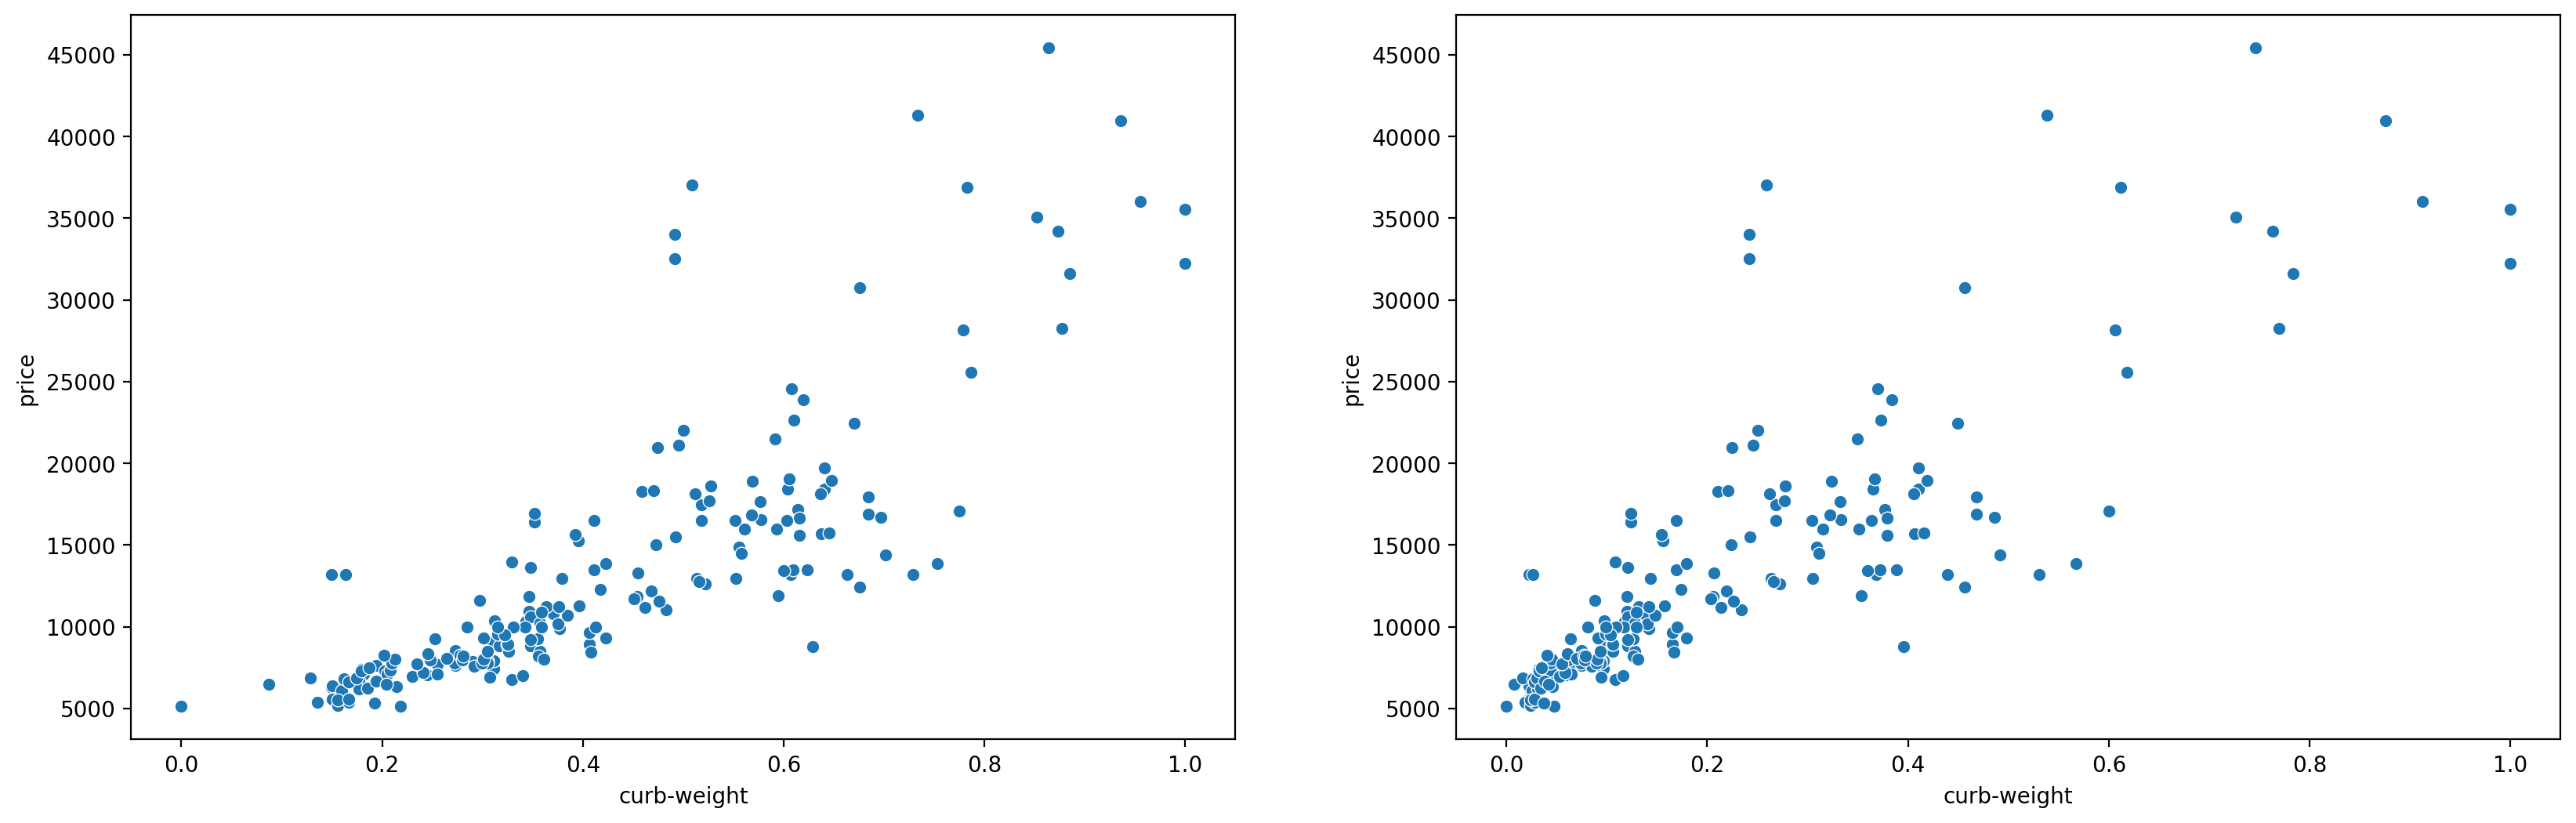

In [82]:
plt.figure(figsize = (20, 6))
plt.subplot(1, 2, 1)
sns.scatterplot(x = X['curb-weight'], y = y)
plt.subplot(1, 2, 2)
sns.scatterplot(x = X['curb-weight'] ** 2, y = y)

<Axes: xlabel='city-mpg', ylabel='price'>

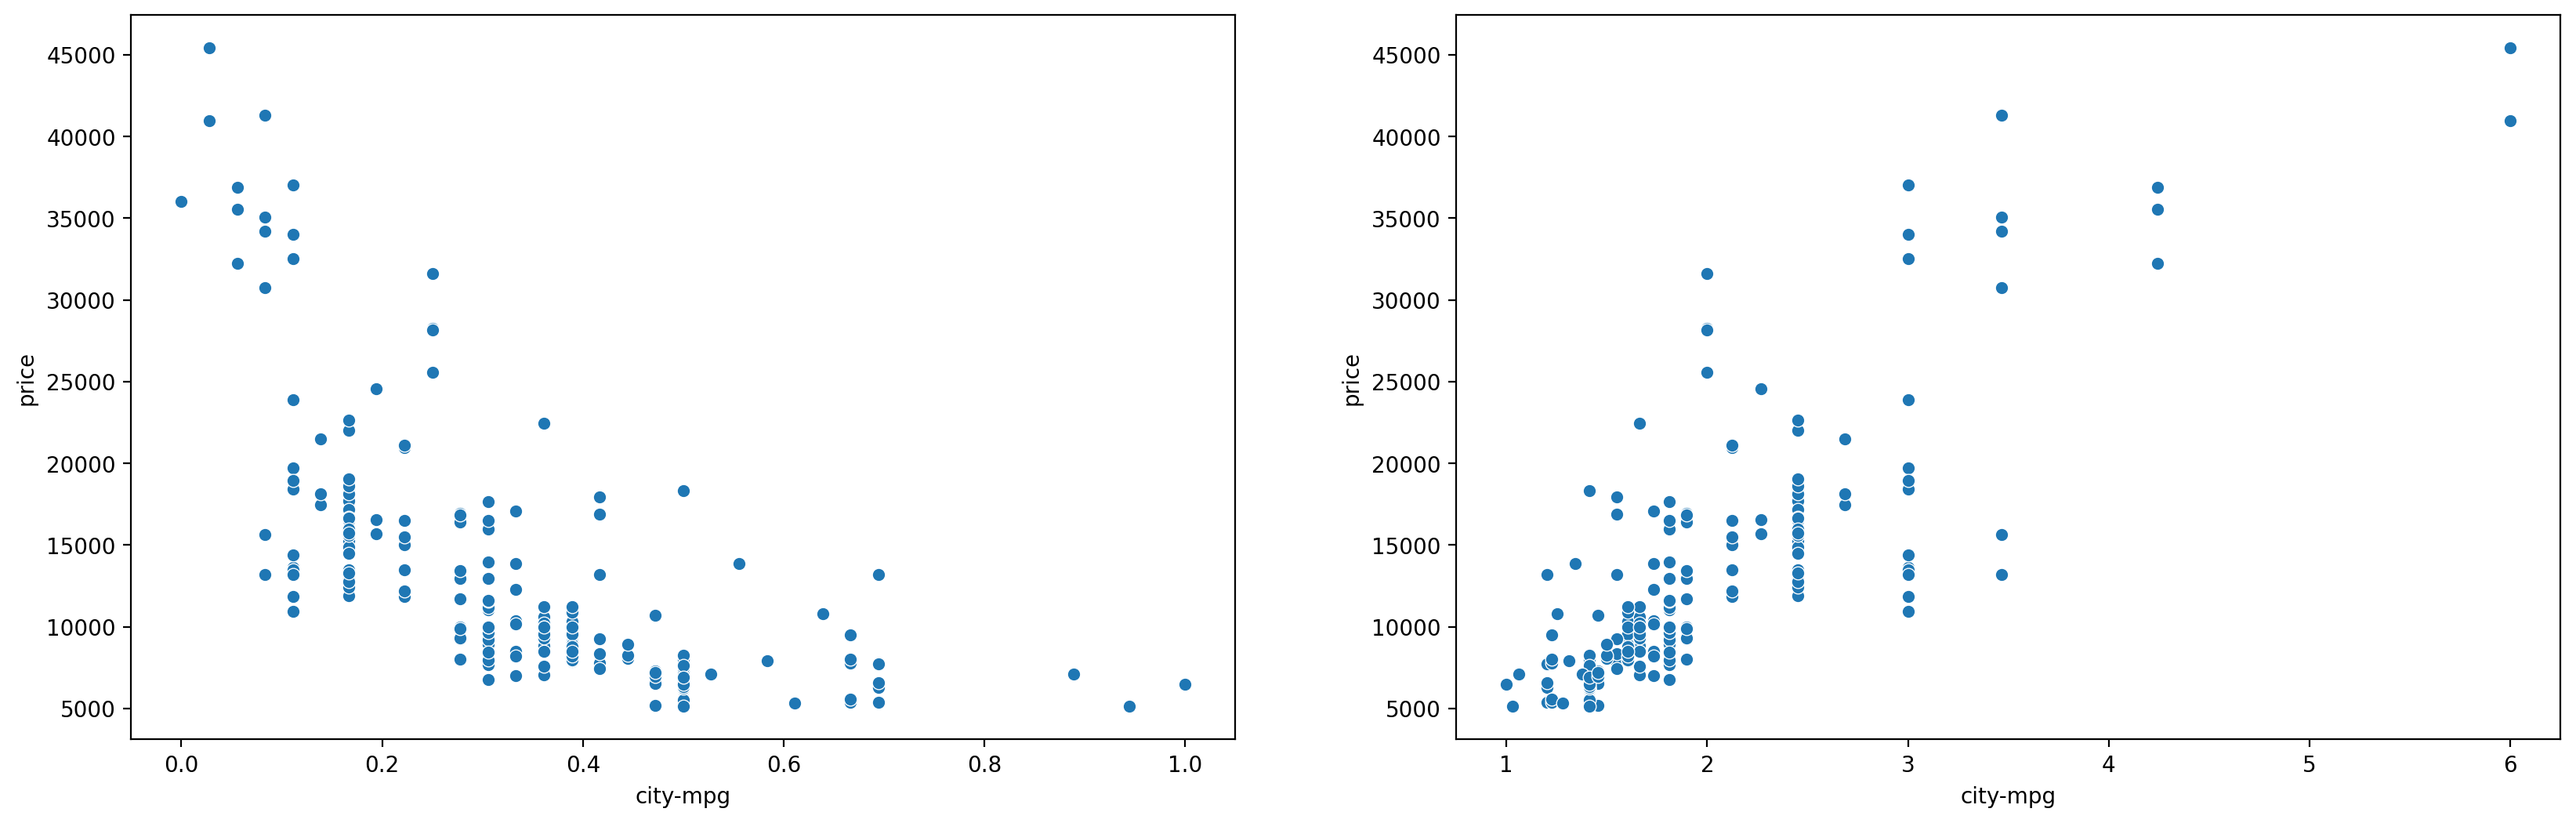

In [83]:
plt.figure(figsize = (20, 6))
plt.subplot(1, 2, 1)
sns.scatterplot(x = X['city-mpg'], y = y)
plt.subplot(1, 2, 2)
sns.scatterplot(x = 1 / np.sqrt(X['city-mpg']), y = y)

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

In [27]:
linear_model = LinearRegression()

In [32]:
y_train

4      17450.0
71     34184.0
134    15040.0
145    11259.0
122     7609.0
        ...   
67     25552.0
192    13845.0
117    18150.0
47     32250.0
172    17669.0
Name: price, Length: 164, dtype: float64

In [33]:
linear_model.fit(X_train, np.array(y_train))

LinearRegression()

In [37]:
y_pred = linear_model.predict(X_test)

In [38]:
y_pred

array([ 5993.03390864, 16412.07124873, 12800.58864855,  -893.2978187 ,
        9464.90605855, 11370.42157268,  6439.18776824,  4427.4433405 ,
       16447.83224628,  8205.26986779, 20628.97698161, 33502.1375356 ,
       12727.8840639 , 14909.25451783,  7720.44203005, 10514.06915131,
       13750.69092381, 18654.92050804,  8431.40477195,  7523.510703  ,
        9499.62947057, 12867.75586213, 14013.08732755, 11630.02818492,
       18079.02018741,  7064.34747355,  7246.96624635, 13128.1412697 ,
        7016.15070885,  5829.50348542,  8495.36155477, 11153.72529488,
       25401.37024091,  9634.78834105,  7520.25813106, 28438.65496719,
       13374.38101656, 14820.45669078,  4092.60251923, 35880.9118654 ,
        6409.06808927])

In [19]:
X_subset = X[['engine-size', 'make_audi']].values

In [20]:
X_subset_outliers = np.vstack((X_subset, [[1, 90], [2, 50]]))  

In [21]:
def scatter_plot_line_mse(dataset, title):
    
    sns.scatterplot(x = dataset[:, 0], y = dataset[:, 1])

    model = LinearRegression()
    model.fit(dataset[:, 0].reshape(-1, 1), dataset[:, 1])

    grid = np.linspace(dataset[:, 0].min(), dataset[:, 0].max(), 100)
    line = model.predict(grid.reshape(-1, 1))
    plt.plot(grid, line, color = 'red')
    plt.ylim(-20, 100)
    plt.title(title)

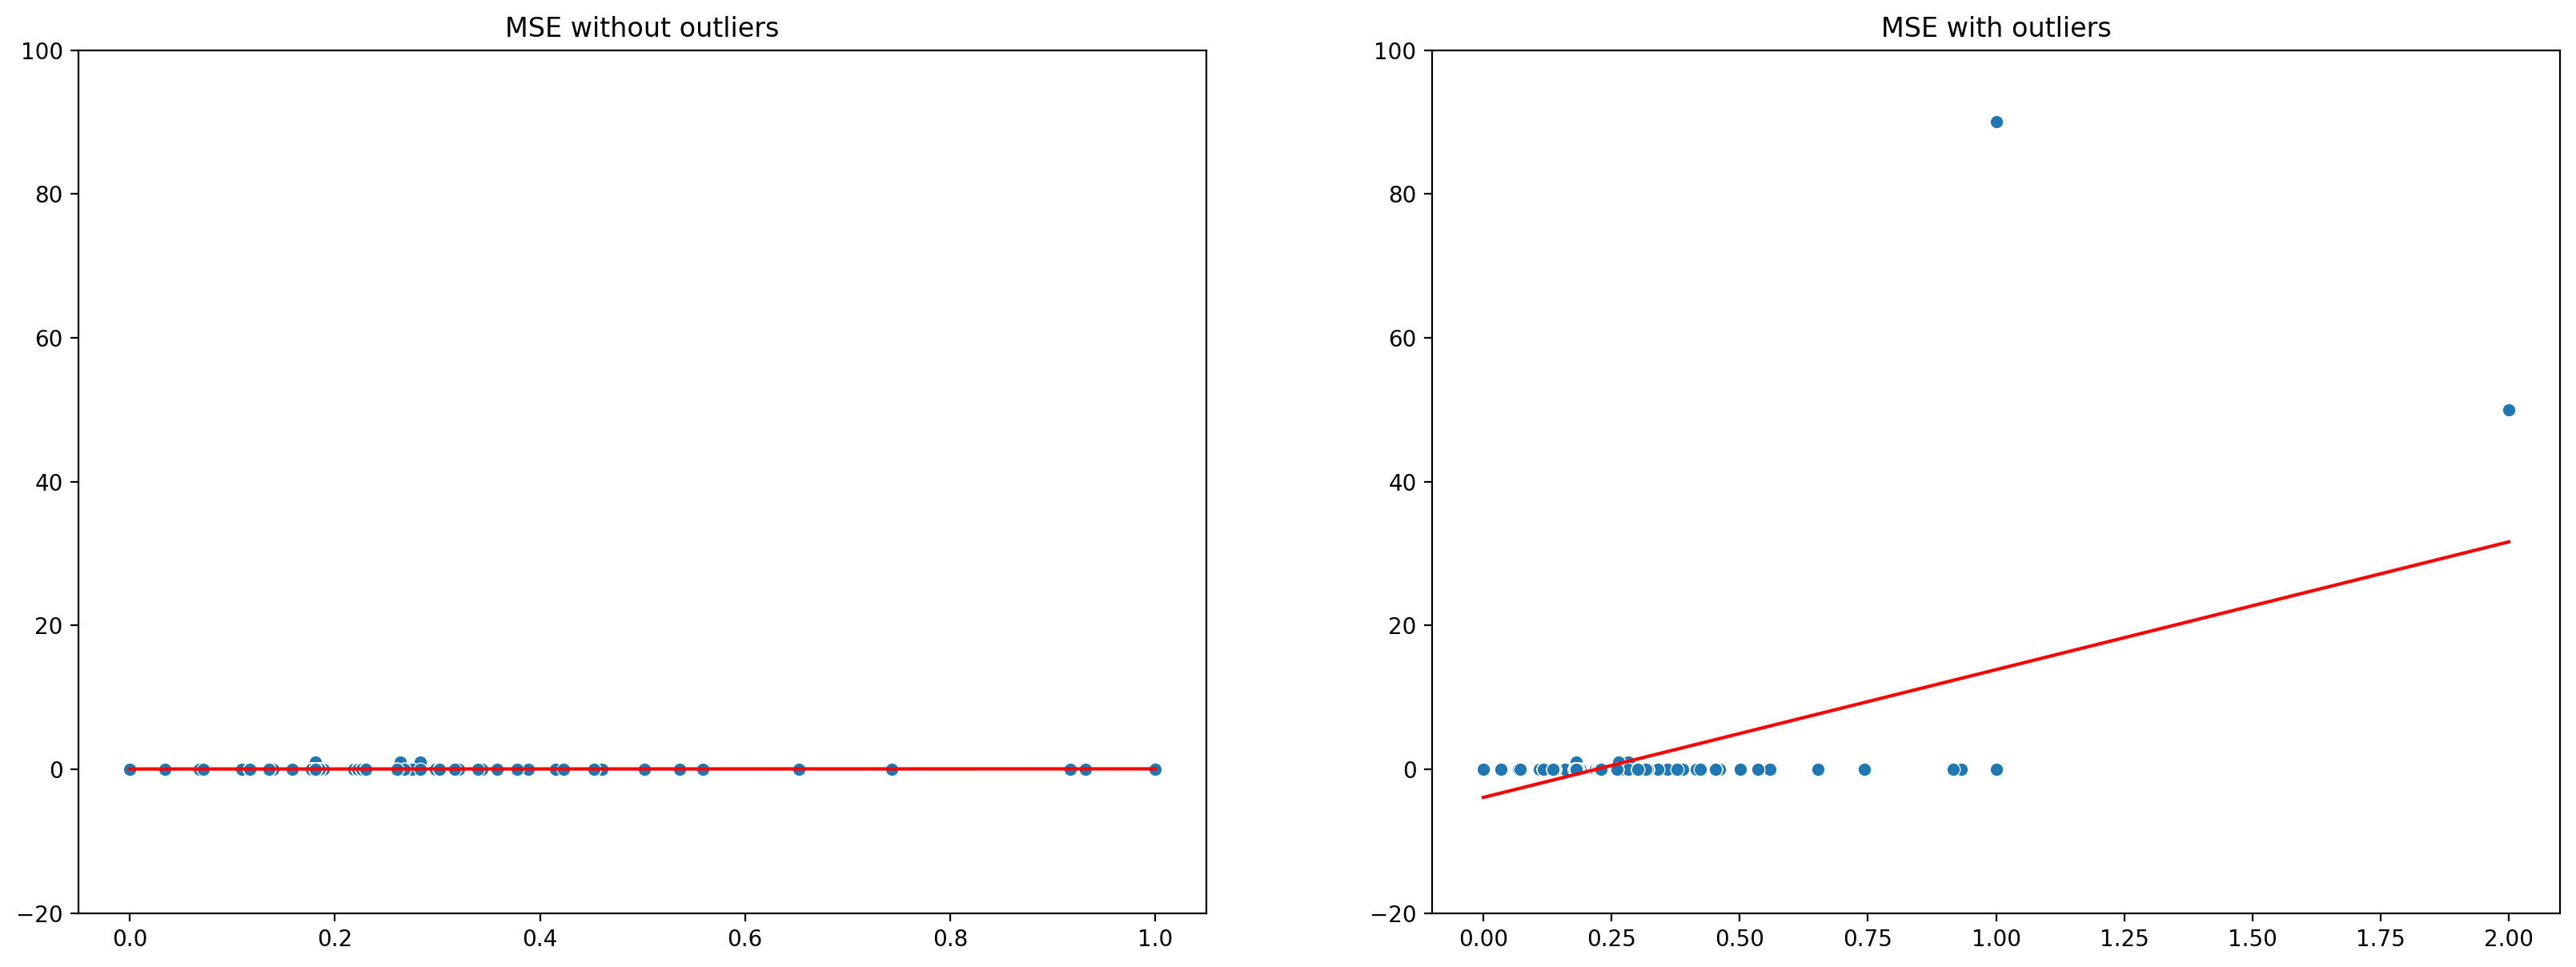

In [22]:
plt.figure(figsize = (20, 7))
plt.subplot(1, 2, 1)
scatter_plot_line_mse(X_subset, 'MSE without outliers')
plt.subplot(1, 2, 2)
scatter_plot_line_mse(X_subset_outliers, 'MSE with outliers')
plt.show();

In [23]:
def MSE(model_test, model_pred):
    return np.sum((model_test - model_pred) ** 2) / len(model_test)

In [39]:
MSE(y_test, y_pred)

np.float64(22499938.662923843)

In [40]:
mean_squared_error(y_test, y_pred)

22499938.662923843

In [41]:
def RMSE(model_test, model_pred):
    return np.sqrt(np.sum((model_test - model_pred) ** 2) / len(model_test))

In [42]:
RMSE(y_test, y_pred)

np.float64(4743.41002475264)

In [45]:
root_mean_squared_error(y_test, y_pred)

4743.41002475264

In [75]:
def R2_Score(y_true, model_pred):
    sum_squared_errors = np.sum((y_true - model_pred) ** 2)
    total_y_squared = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - sum_squared_errors / total_y_squared

In [72]:
R2_Score(y_test, y_pred)

np.float64(0.6709101387100544)

In [73]:
r2_score(y_test, y_pred)

0.6709101387100544

In [74]:
def MAE(true, pred):
    return np.sum(np.abs(true - pred)) / len(true)

In [77]:
MAE(y_test, y_pred)

np.float64(2821.870536352143)

In [76]:
mean_absolute_error(y_test, y_pred)

2821.870536352143

In [78]:
from sklearn.linear_model import QuantileRegressor

In [79]:
def scatter_plot_line_mae(dataset, title):
    
    sns.scatterplot(x = dataset[:, 0], y = dataset[:, 1])

    model = QuantileRegressor(quantile = 0.5, alpha = 0)
    model.fit(dataset[:, 0].reshape(-1, 1), dataset[:, 1])

    grid = np.linspace(dataset[:, 0].min(), dataset[:, 0].max(), 100)
    line = model.predict(grid.reshape(-1, 1))
    plt.plot(grid, line, color = 'red')
    plt.ylim(-20, 100)
    plt.title(title)

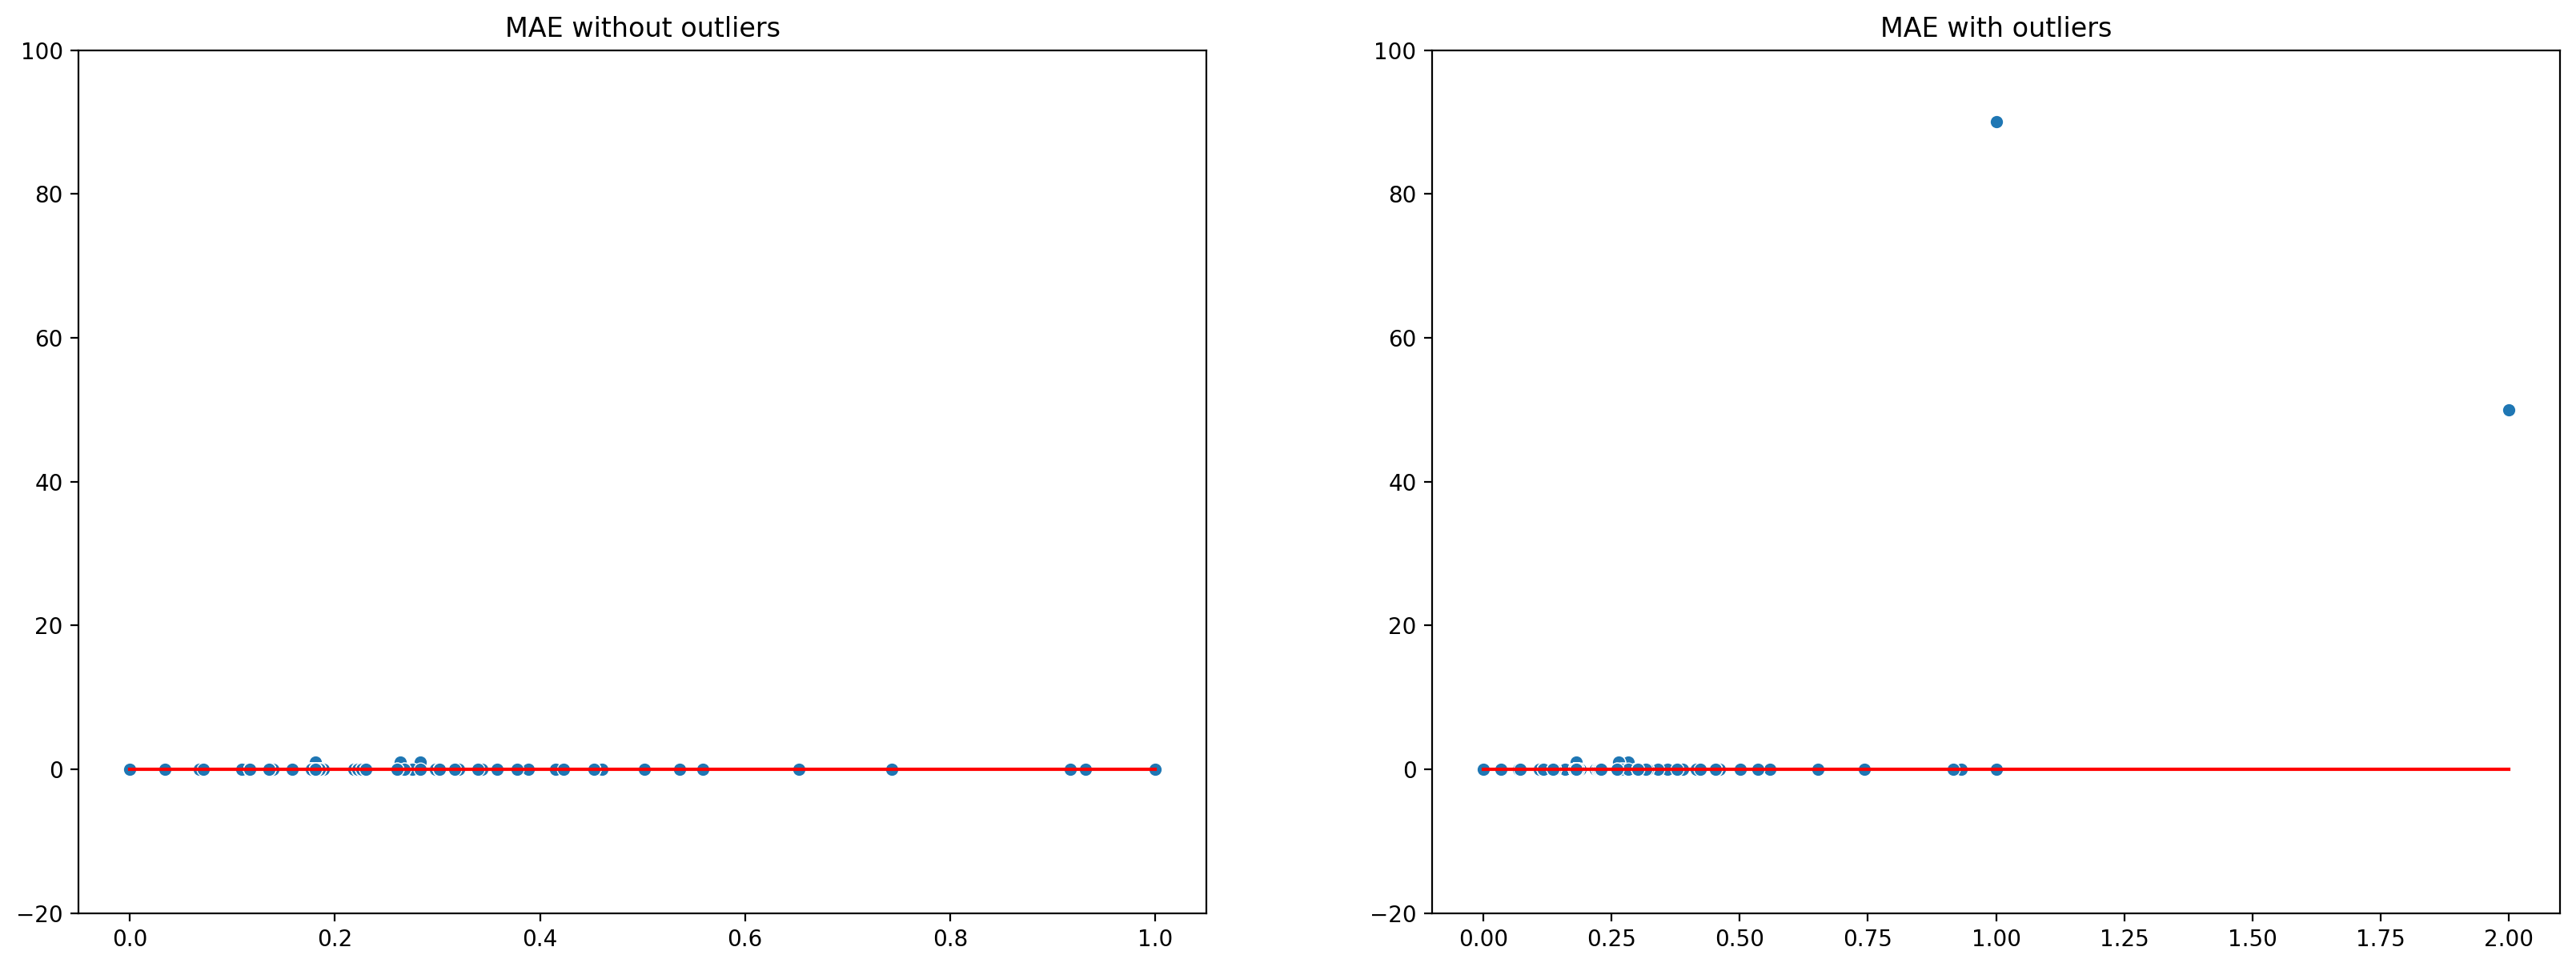

In [80]:
plt.figure(figsize = (20, 7))
plt.subplot(1, 2, 1)
scatter_plot_line_mae(X_subset, 'MAE without outliers')
plt.subplot(1, 2, 2)
scatter_plot_line_mae(X_subset_outliers, 'MAE with outliers')
plt.show();